# Вариационный автокодировщик (VAE) на PyTorch

**Автокодировщик** — нейросеть, которая учится сжимать данные в низкоразмерное представление, а затем восстанавливать их обратно. В отличие от обычной модели, нам интересен не сам вывод, а **латентный вектор** `z` — компактный «смысл» объекта.

**Вариационный автокодировщик (VAE)** добавляет в эту схему вероятностную интерпретацию: на вход декодеру подаётся не точка, а распределение. Это позволяет **генерировать новые объекты**: берём случайную точку из стандартного нормального распределения и прогоняем через декодер.

В этом ноутбуке обучим VAE на цветных картинках **CIFAR-10**.

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import torchvision
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split

In [4]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("PyTorch:", torch.__version__)
print("CUDA доступна:", torch.cuda.is_available())
print("Устройство:", device)

PyTorch: 2.1.2+cu121
CUDA доступна: True
Устройство: cuda:0


## Данные: CIFAR-10

**CIFAR-10** — набор из 60 000 цветных фотографий 32×32 (по 3 канала: RGB), разбитых на 10 классов:

- самолёт, автомобиль, птица, кошка, олень, собака, лягушка, лошадь, корабль, грузовик.

Каждое изображение — вектор из $32 \times 32 \times 3 = 3072$ чисел в диапазоне `[0, 1]`.

Загрузим данные. Если CIFAR-10 недоступен (нет интернета), ноутбук автоматически откатится на MNIST или датасет рукописных цифр из scikit-learn — так код гарантированно заработает в любом окружении.

In [5]:
data_dir = "../Computer-Vision-Course_lec-practice_old/2025/data/"
IMG = 32
CHANNELS = 3
DATASET_NAME = "CIFAR-10"
x_train = None
labels = None

def load_cifar():
    cifar = torchvision.datasets.CIFAR10(root=data_dir, train=True, download=True)
    return torch.from_numpy(np.asarray(cifar.data)), torch.tensor(cifar.targets)

try:
    data_raw, labels = load_cifar()
    x_train = data_raw.float() / 255.0          # (50000, 32, 32, 3), пиксели в [0, 1]
    IMG, CHANNELS, DATASET_NAME = 32, 3, "CIFAR-10"
except Exception as e:
    print("CIFAR-10 недоступен, пробуем MNIST:", e)
    try:
        mnist = torchvision.datasets.MNIST(root=data_dir, train=True, download=True)
        x_train = mnist.data.float() / 255.0
        labels = mnist.targets
        IMG, CHANNELS, DATASET_NAME = 28, 1, "MNIST"
    except Exception as e2:
        print("MNIST тоже недоступен, откат на sklearn digits:", e2)
        from sklearn.datasets import load_digits
        digits = load_digits()
        x_train = torch.from_numpy(digits.data / 16.0)
        labels = torch.tensor(digits.target)
        IMG, CHANNELS, DATASET_NAME = 8, 1, "sklearn digits"

# Для линейного VAE превращаем картинки в плоские векторы
x_flat = x_train.reshape(x_train.size(0), -1)

print(f"Набор данных: {DATASET_NAME}, {x_train.size(0)} изображений {IMG}x{IMG}"
      f" ({'RGB' if CHANNELS == 3 else 'градации серого'})")
print(f"Размер тензора данных: {tuple(x_flat.shape)}")

Files already downloaded and verified
Набор данных: CIFAR-10, 50000 изображений 32x32 (RGB)
Размер тензора данных: (50000, 3072)


## Идея VAE

Пусть `x` — изображение (вектор из $32 \times 32 \times 3$ чисел), а `z` — вектор признаков в латентном пространстве.

1. **Энкодер** $q_\phi(z|x)$ выводит параметры нормального распределения: среднее `mu` и логарифм дисперсии `logvar`.
2. **Репараметризация**: чтобы можно было обучать через backpropagation, точка `z` получается как `mu + sigma * eps`, где `eps` — шум из $N(0, I)$.
3. **Декодер** $p_\theta(x|z)$ восстанавливает изображение по `z`.

Модель учится максимизировать **нижнюю границу правдоподобия (ELBO)**:

$$\log p(x) \geq \underbrace{\mathbb{E}_{z\sim q}[\log p(x|z)]}_{\text{качество реконструкции}} - \underbrace{KL\big(q(z|x) \,\|\, p(z)\big)}_{\text{регуляризация}}$$

Kullback-Leibler-дивергенция заставляет распределение $q(z|x)$ быть близким к априорному $p(z)=N(0, I)$: тогда из любой точки «стандартной» колокольной кривой получается правдоподобный объект.

In [6]:
class VAE(nn.Module):
    def __init__(self, input_dim, latent_dim=32, hidden_dim=512):
        super().__init__()
        # Энкодер: x -> h -> (mu, logvar)
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)
        # Декодер: z -> h -> x'
        self.fc3 = nn.Linear(latent_dim, hidden_dim)
        self.fc4 = nn.Linear(hidden_dim, input_dim)

    def encode(self, x):
        h = F.relu(self.fc1(x))
        return self.fc_mu(h), self.fc_logvar(h)

    # Трюк репараметризации: z = mu + sigma * eps
    def reparametrize(self, mu, logvar):
        sigma = torch.exp(0.5 * logvar)
        eps = torch.randn_like(sigma)
        return mu + sigma * eps

    def decode(self, z):
        h = F.relu(self.fc3(z))
        return self.fc4(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparametrize(mu, logvar)
        x_recon = torch.sigmoid(self.decode(z))
        return x_recon, mu, logvar

In [7]:
def loss_function(x, x_recon, mu, logvar):
    # 1) Качество реконструкции (перекрёстная энтропия) - это минус log p(x|z).
    #    Для двоичных изображений (MNIST) правилен BCE, а для вещественных
    #    пикселей в [0,1] (CIFAR-10) - среднеквадратичная ошибка (MSE):
    recon_loss = F.mse_loss(x_recon, x, reduction="sum")
    # 2) Регуляризирующий член: KL( q(z|x) || N(0, I) ).
    #    Формула одинакова для обоих вариантов:
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kl_loss, recon_loss, kl_loss

## Конфигурация и загрузка данных

Латентная размерность `latent_dim = 32` типична для VAE. Отдаём 90% данных на обучение и 10% - на контроль качества реконструкции (валидацию).

In [8]:
latent_dim = 32
batch_size = 512
epochs = 55
lr = 1e-3

train_idx, val_idx = train_test_split(np.arange(x_flat.size(0)), test_size=0.1, random_state=42)
train_loader = DataLoader(TensorDataset(x_flat[train_idx], labels[train_idx]),
                          batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(TensorDataset(x_flat[val_idx], labels[val_idx]),
                        batch_size=batch_size, shuffle=False, num_workers=2)

vae = VAE(input_dim=x_flat.size(1), latent_dim=latent_dim).to(device)
n_params = sum(p.numel() for p in vae.parameters())
print(f"Размерность входа: {x_flat.size(1)} | Скрытый слой: 512")
print(f"Количество параметров: {n_params:,}")
print(f"Латентная размерность: {latent_dim}")

Размерность входа: 3072 | Скрытый слой: 512
Количество параметров: 3,199,040
Латентная размерность: 32


## Обучение

На каждом шаге: прогоняем батч через VAE, считаем потери, обновляем веса Адамом. Смотрим, как уменьшается сумма потерь и как разделяются её две составляющие.

In [9]:
optimizer = torch.optim.Adam(vae.parameters(), lr=lr)

print("Обучение...")
history = []
for epoch in range(1, epochs + 1):
    vae.train()
    total = recon = kl = 0.0
    for xb, _ in train_loader:
        xb = xb.to(device)
        optimizer.zero_grad()
        x_recon, mu, logvar = vae(xb)
        loss, r, k = loss_function(xb, x_recon, mu, logvar)
        loss.backward()
        optimizer.step()
        total += loss.item(); recon += r.item(); kl += k.item()
    n = len(train_loader.dataset)
    history.append(total / n)
    print(f"Эпоха {epoch:3d} | loss {total/n:8.2f} | реконструкция {recon/n:8.2f} | KL {kl/n:8.2f}")

torch.save(vae.state_dict(), "vae_cifar10.pth")
print("Модель сохранена в файл vae_cifar10.pth")

Обучение...
Эпоха   1 | loss   156.40 | реконструкция   148.41 | KL     8.00
Эпоха   2 | loss   117.55 | реконструкция   102.70 | KL    14.85
Эпоха   3 | loss   102.48 | реконструкция    85.63 | KL    16.84
Эпоха   4 | loss    96.06 | реконструкция    79.04 | KL    17.02
Эпоха   5 | loss    93.08 | реконструкция    76.25 | KL    16.83
Эпоха   6 | loss    90.86 | реконструкция    74.11 | KL    16.75
Эпоха   7 | loss    89.74 | реконструкция    72.91 | KL    16.83
Эпоха   8 | loss    88.46 | реконструкция    71.52 | KL    16.93
Эпоха   9 | loss    87.78 | реконструкция    70.86 | KL    16.92
Эпоха  10 | loss    87.37 | реконструкция    70.49 | KL    16.88
Эпоха  11 | loss    86.48 | реконструкция    69.47 | KL    17.01
Эпоха  12 | loss    85.61 | реконструкция    68.34 | KL    17.27
Эпоха  13 | loss    84.91 | реконструкция    67.41 | KL    17.50
Эпоха  14 | loss    84.54 | реконструкция    66.96 | KL    17.58
Эпоха  15 | loss    84.11 | реконструкция    66.45 | KL    17.66
Эпоха  16 | l

## Смотрим график потерь

Нижняя граница правдоподобия (ELBO) должна стабильно убывать. Если она не падает — попробуйте уменьшить learning rate или увеличить скрытый слой.

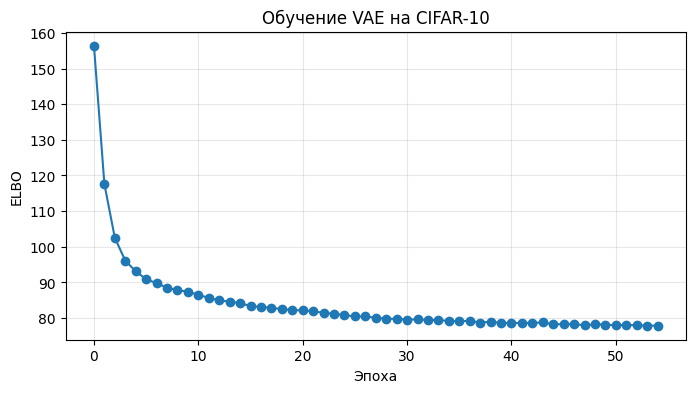

In [16]:
plt.figure(figsize=(8, 4))
plt.plot(history, marker="o")
plt.xlabel("Эпоха")
plt.ylabel("ELBO")
plt.title("Обучение VAE на CIFAR-10")
plt.grid(alpha=0.3)
plt.show()

## Восстановление и генерация

Сначала убедимся, что модель научилась сжимать и восстанавливать картинки. Нарисуем 10 исходных изображений подряд и их реконструкции. Ожидается, что CIFAR-10 из-за большой размерности входов покажет «замыленное» качество — это нормально для простого линейного VAE: чёткость появляется у свёрточных вариантов.

Исходные изображения


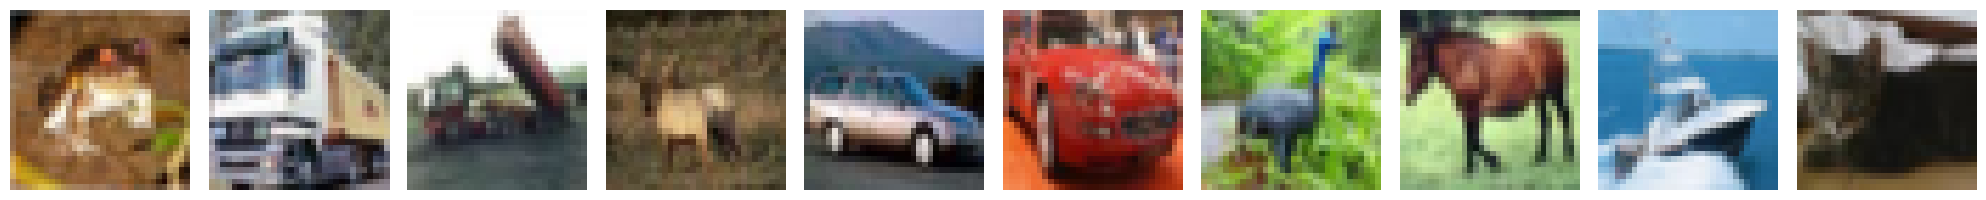

Реконструкция


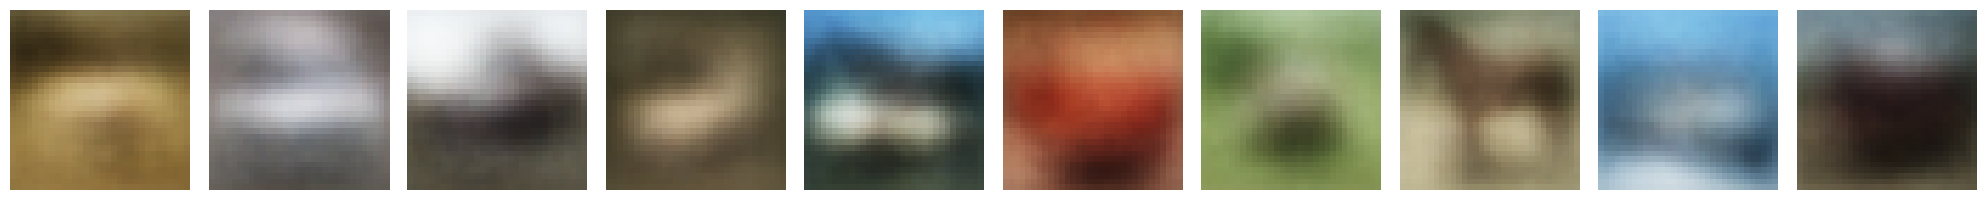

In [17]:
def view_img(arr):
    if arr.ndim == 1:
        shape = (IMG, IMG, CHANNELS) if CHANNELS == 3 else (IMG, IMG)
        arr = arr.reshape(shape)
    return arr

def show_row(images, cmap=None, title=None):
    images = [view_img(img.cpu().numpy() if torch.is_tensor(img) else img) for img in images]
    fig, axes = plt.subplots(1, len(images), figsize=(2 * len(images), 2.1))
    if len(images) == 1:
        axes = [axes]
    for ax, img in zip(axes, images):
        ax.imshow(img, cmap=cmap)
        ax.axis("off")
    if title:
        fig.suptitle(title, fontsize=11)
    plt.tight_layout()
    plt.show()

cmap = None if CHANNELS == 3 else "gray"

vae.eval()
with torch.no_grad():
    xb = x_flat[:10].to(device)
    recon_x, mu, logvar = vae(xb)

print("Исходные изображения")
show_row(x_train[:10], cmap)
print("Реконструкция")
show_row(recon_x, cmap)

### Генерация новых изображений

Берём случайные точки из стандартного нормального распределения $N(0, I)$ и прогоняем через декодер. Это и есть **генеративная** часть VAE.

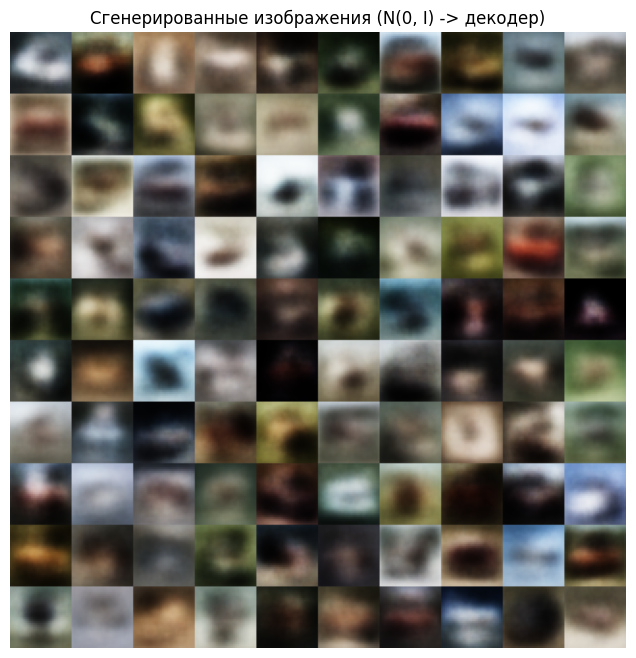

In [18]:
with torch.no_grad():
    z = torch.randn(100, latent_dim).to(device)
    gen = torch.sigmoid(vae.decode(z))

gen = gen.cpu()
if CHANNELS == 3:
    grid = gen.reshape(10, 10, IMG, IMG, CHANNELS).permute(0, 2, 1, 3, 4).reshape(10 * IMG, 10 * IMG, CHANNELS)
else:
    grid = gen.reshape(10, 10, IMG, IMG).permute(0, 2, 1, 3).reshape(10 * IMG, 10 * IMG)

plt.figure(figsize=(8, 8))
plt.imshow(view_img(grid))
plt.axis("off")
plt.title("Сгенерированные изображения (N(0, I) -> декодер)")
plt.show()

## Линейная интерполяция в латентном пространстве

Возьмём изображения двух разных классов (птица и собака), получим их латентные векторы и **плавно** пройдём от одного к другому. Если латентное пространство осмысленно, между ними будут получаться промежуточные изображения-гибриды.

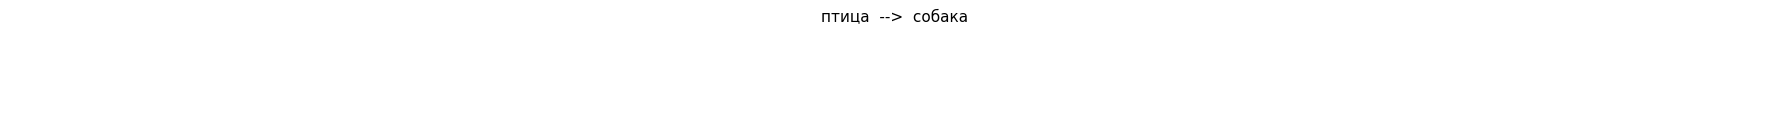

In [19]:
class_names = ["самолёт", "автомобиль", "птица", "кошка", "олень",
              "собака", "лягушка", "лошадь", "корабль", "грузовик"]

def first_index_of(label_value):
    return int((labels == label_value).nonzero()[0][0])

cls_a, cls_b = 2, 5   # птица -> собака
img_a_id = first_index_of(cls_a)
img_b_id = first_index_of(cls_b)

with torch.no_grad():
    mu_a, _ = vae.encode(x_flat[img_a_id:img_a_id + 1].to(device))
    mu_b, _ = vae.encode(x_flat[img_b_id:img_b_id + 1].to(device))

alphas = torch.linspace(0, 1, 9)
imgs = []
with torch.no_grad():
    for alpha in alphas:
        z = mu_a * (1 - alpha) + mu_b * alpha
        imgs.append(torch.sigmoid(vae.decode(z)))

show_row(imgs, cmap, title=f"{class_names[cls_a]}  -->  {class_names[cls_b]}")

## Бонус: латентное пространство в 2 измерениях

Если взять `latent_dim = 2`, весь латентный вектор можно нарисовать на плоскости. Обучим ещё одну модель с двумерным латентным пространством и посмотрим, как классы распределятся по нему.

In [20]:
n_epochs_2d = 30
vae2 = VAE(input_dim=x_flat.size(1), latent_dim=2).to(device)
opt2 = torch.optim.Adam(vae2.parameters(), lr=1e-3)
train_loader2 = DataLoader(TensorDataset(x_flat, labels), batch_size=batch_size, shuffle=True)

for epoch in range(1, n_epochs_2d + 1):
    vae2.train()
    total = 0.0
    for xb, _ in train_loader2:
        xb = xb.to(device)
        opt2.zero_grad()
        x_recon, mu, logvar = vae2(xb)
        loss, _, _ = loss_function(xb, x_recon, mu, logvar)
        loss.backward()
        opt2.step()
        total += loss.item()
    print(f"Эпоха {epoch:3d} | обучение 2D-VAE | loss {total / len(train_loader2.dataset):8.2f}")

Эпоха   1 | обучение 2D-VAE | loss   147.60
Эпоха   2 | обучение 2D-VAE | loss   125.21
Эпоха   3 | обучение 2D-VAE | loss   122.79
Эпоха   4 | обучение 2D-VAE | loss   121.51
Эпоха   5 | обучение 2D-VAE | loss   121.32
Эпоха   6 | обучение 2D-VAE | loss   121.30
Эпоха   7 | обучение 2D-VAE | loss   120.36
Эпоха   8 | обучение 2D-VAE | loss   120.27
Эпоха   9 | обучение 2D-VAE | loss   120.22
Эпоха  10 | обучение 2D-VAE | loss   120.01
Эпоха  11 | обучение 2D-VAE | loss   119.86
Эпоха  12 | обучение 2D-VAE | loss   119.61
Эпоха  13 | обучение 2D-VAE | loss   119.44
Эпоха  14 | обучение 2D-VAE | loss   119.07
Эпоха  15 | обучение 2D-VAE | loss   119.04
Эпоха  16 | обучение 2D-VAE | loss   118.72
Эпоха  17 | обучение 2D-VAE | loss   118.51
Эпоха  18 | обучение 2D-VAE | loss   118.12
Эпоха  19 | обучение 2D-VAE | loss   118.21
Эпоха  20 | обучение 2D-VAE | loss   117.90
Эпоха  21 | обучение 2D-VAE | loss   117.63
Эпоха  22 | обучение 2D-VAE | loss   117.53
Эпоха  23 | обучение 2D-VAE | lo

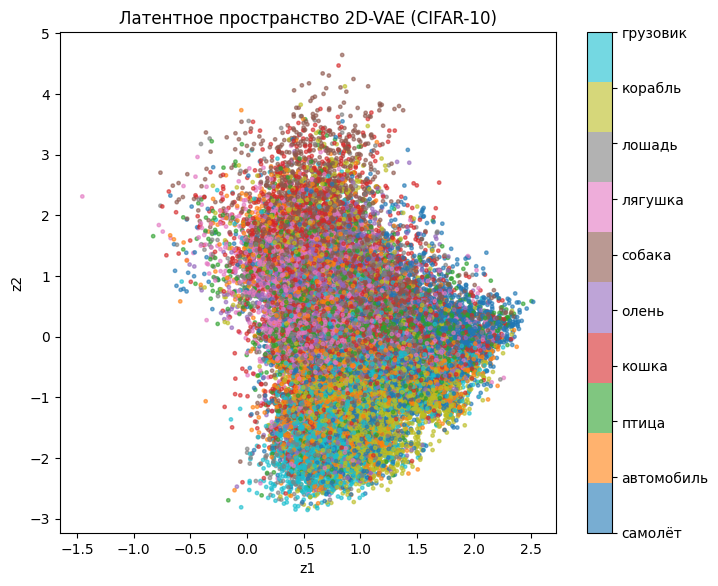

In [21]:
vae2.eval()
with torch.no_grad():
    mus, ys = [], []
    for xb, yb in DataLoader(TensorDataset(x_flat, labels), batch_size=2048, shuffle=False):
        mu, _ = vae2.encode(xb.to(device))
        mus.append(mu.cpu()); ys.append(yb)
mus = torch.cat(mus); ys = torch.cat(ys).numpy()

plt.figure(figsize=(8, 6.5))
sc = plt.scatter(mus[:, 0].numpy(), mus[:, 1].numpy(), c=ys, cmap="tab10", s=6, alpha=0.6)
plt.colorbar(sc, ticks=range(10)).ax.set_yticklabels(class_names)
plt.xlabel("z1")
plt.ylabel("z2")
plt.title("Латентное пространство 2D-VAE (CIFAR-10)")
plt.show()

## Заключение

Вариационный автокодировщик — простой, но очень наглядный пример генеративной модели. На натуральных изображениях (CIFAR-10) линейный VAE даёт лишь замыленные эскизы — это главный компромисс генеративных моделей: **правдоподобность против чёткости**.

Путь к качеству:

- свёрточные энкодер/декодер (реализовано в задании 2);
- _β_-VAE — аккуратнее регуляризация латентного пространства;
- VQ-VAE (дискретные латентные векторы) — применяется в звуке и изображениях;
- диффузионные модели и GAN — современная альтернатива с более чёткими картинками.

## Ссылки

- Kingma, Welling. *Auto-Encoding Variational Bayes*, 2013. https://arxiv.org/abs/1312.6114
- Higgins et al. *β-VAE: Learning Basic Visual Concepts with a Constrained Variational Framework*. https://openreview.net/forum?id=Sy2fzU9gl